In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [4]:
hdul_I = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul_I.info()
image_I = hdul_I[0].data
image_error_I = hdul_I[1].data
hdul_P = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Paola_red/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
image_P = hdul_P[0].data
image_error_P = hdul_P[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [5]:
image_cut_I = image_I[55:155, 0:1890]
image_error_cut_I = image_error_I[55:155, 0:1890]
image_cut_P = image_P[55:155, 0:1890]
image_error_cut_P = image_error_P[55:155, 0:1890]

Text(0.5, 0, 'wavelenght')

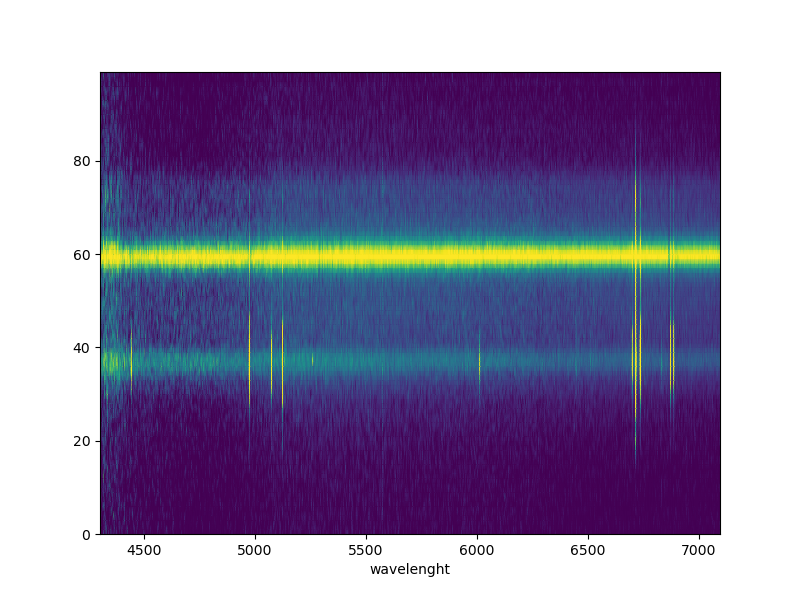

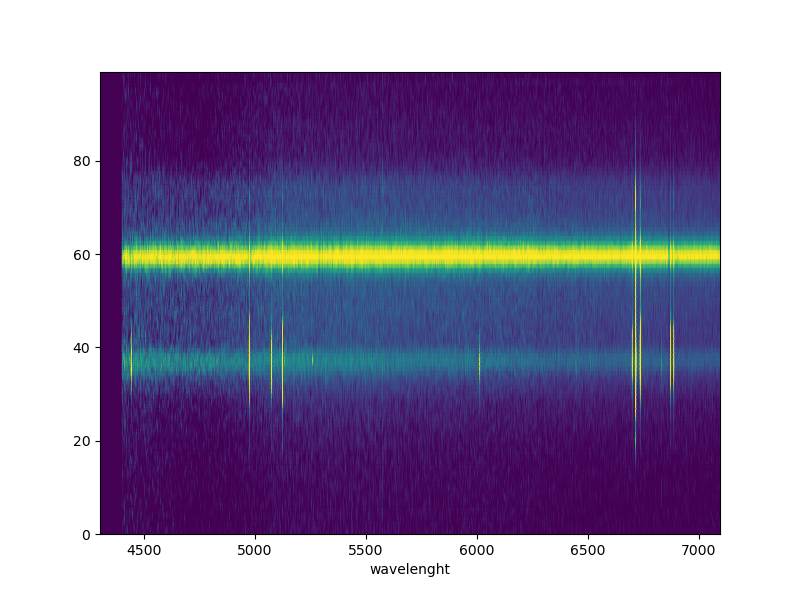

In [16]:
plt.figure(figsize=(8,6))
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut_I.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut_I, shading='gouraud', vmin = np.percentile(image_cut_I, 20), vmax = 0.16)
plt.xlabel('wavelenght')

plt.figure(figsize=(8,6))
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut_P.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut_P, shading='gouraud', vmin = np.percentile(image_cut_P, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [9]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [11]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

NameError: name 'image_cut' is not defined

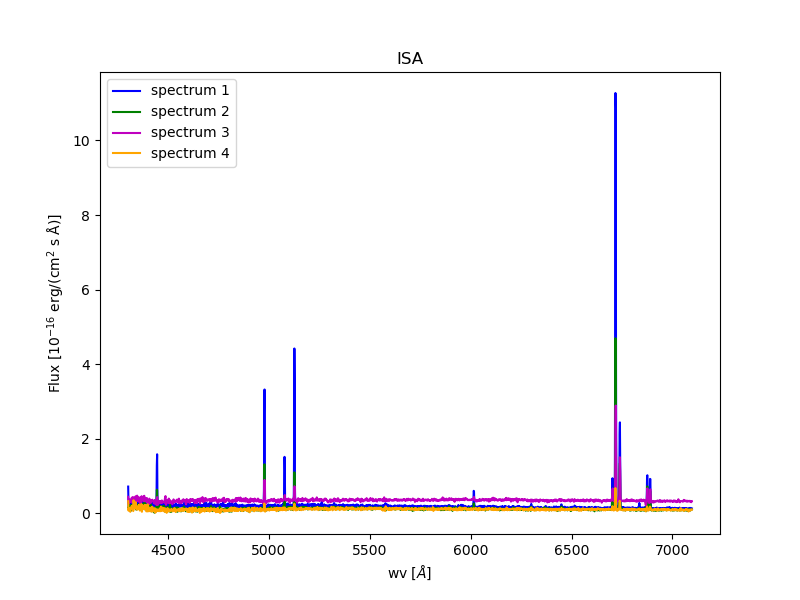

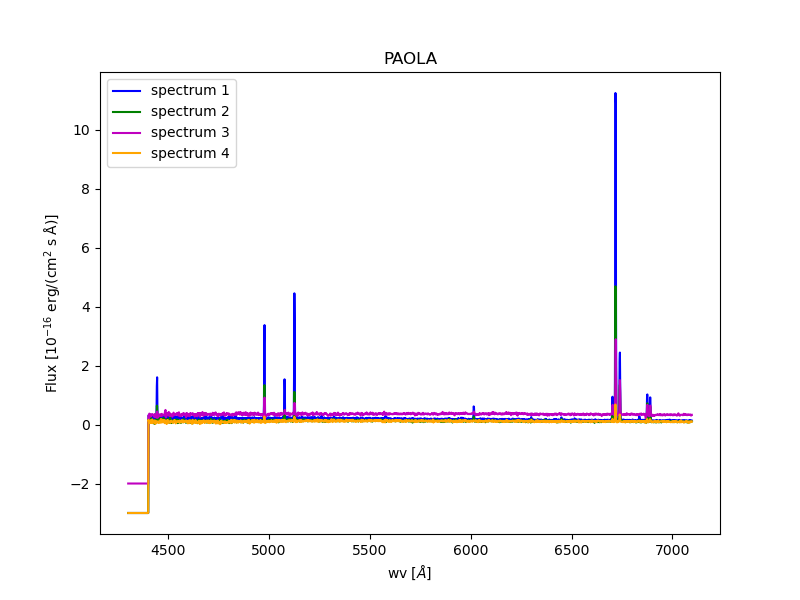

In [26]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)
x_axes = np.arange(0, 100, 1)
seeing = 3.174 #in pixels
sigma = seeing/2.35
peaks = fit_HA.iloc[3].values

plt.figure(figsize=(8,6))
spectra_I =  np.zeros((len(peaks), image_cut_I.shape[1]))
spectra_err_I = np.zeros((len(peaks), image_error_cut_I.shape[1]))
colors = ['blue', 'green', 'm', 'orange']

#ISA
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-sigma)*(x_axes < peaks[i]+sigma)
    spectra_I[i] = np.sum(image_cut_I[mask, :], axis = 0)
    spectra_err_I[i] = np.sqrt(np.sum(image_error_cut_I[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_I[i], color = colors[i], label = f'spectrum {i+1}')
    plt.title('ISA')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
plt.figure(figsize=(8,6))
spectra_P =  np.zeros((len(peaks), image_cut_P.shape[1]))
spectra_err_P = np.zeros((len(peaks), image_error_cut_P.shape[1]))

#PAOLA
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]- sigma)*(x_axes < peaks[i]+ sigma)
    spectra_P[i] = np.sum(image_cut_P[mask, :], axis = 0)
    spectra_err_P[i] = np.sqrt(np.sum(image_error_cut_P[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y)
    plt.title('PAOLA')
    plt.plot(wv, spectra_P[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    

Text(0, 0.5, 'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')

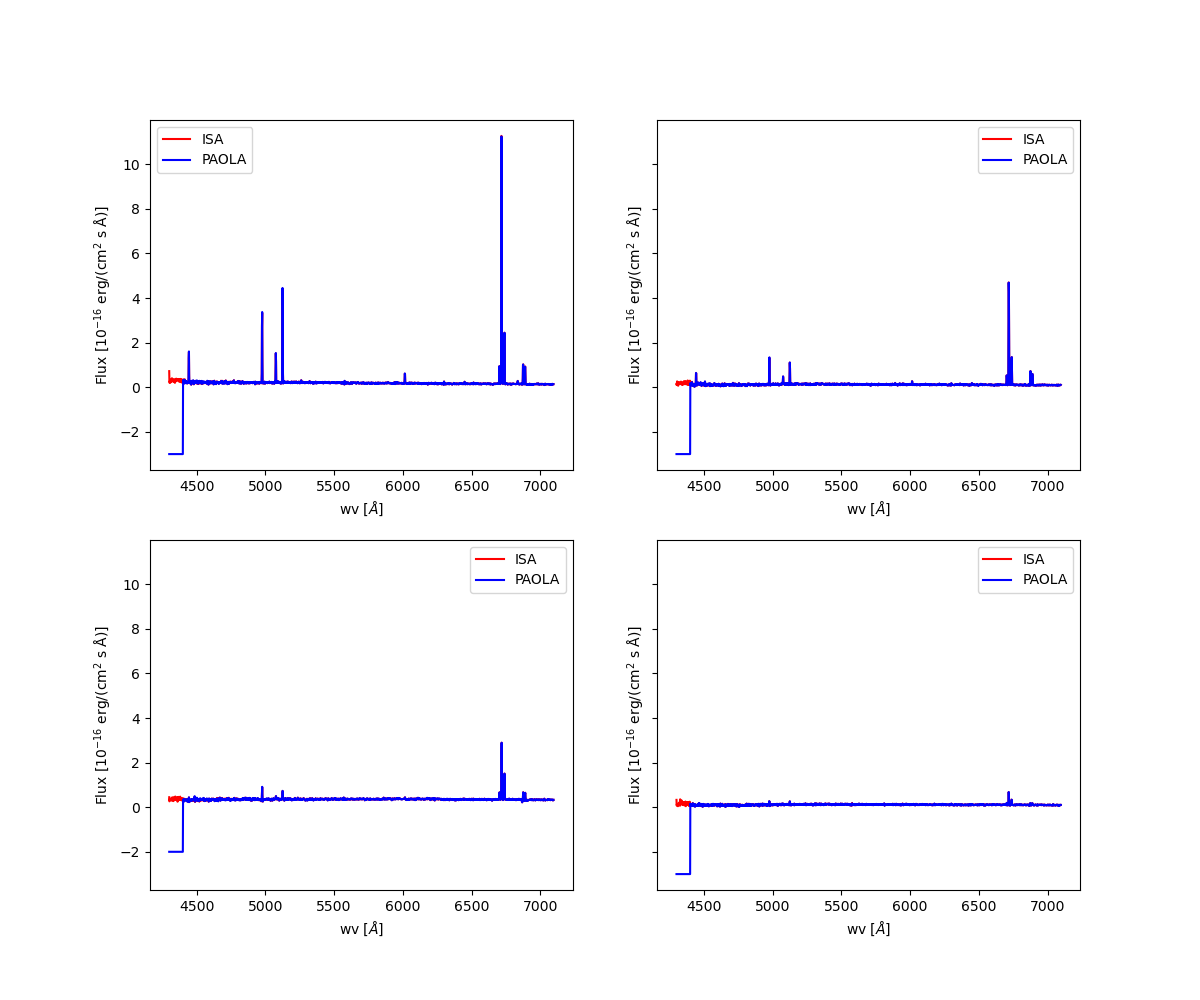

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10), sharey = True)

ax[0][0].plot(wv, spectra_I[0], color = 'red', label = 'ISA')
ax[0][0].plot(wv, spectra_P[0], color = 'blue', label = 'PAOLA')
ax[0][0].legend()
ax[0][0].set_xlabel(r'wv [$\AA$]')
ax[0][0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')

ax[0][1].plot(wv, spectra_I[1], color = 'red', label = 'ISA')
ax[0][1].plot(wv, spectra_P[1], color = 'blue', label = 'PAOLA')
ax[0][1].legend()
ax[0][1].set_xlabel(r'wv [$\AA$]')
ax[0][1].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')

ax[1][0].plot(wv, spectra_I[2], color = 'red', label = 'ISA')
ax[1][0].plot(wv, spectra_P[2], color = 'blue', label = 'PAOLA')
ax[1][0].legend()
ax[1][0].set_xlabel(r'wv [$\AA$]')
ax[1][0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')

ax[1][1].plot(wv, spectra_I[3], color = 'red', label = 'ISA')
ax[1][1].plot(wv, spectra_P[3], color = 'blue', label = 'PAOLA')
ax[1][1].legend()
ax[1][1].set_xlabel(r'wv [$\AA$]')
ax[1][1].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
